In [39]:
### Project : Sales & Profit Analysis.
### Objective : Analyze Sales, Profit & Customer behavior to derive business insights.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "Order_ID":[201,202,203,204,205,206,207,208,209,210],
    "Order_Date":["01-02-2024","03-02-2024","05-02-2024","07-02-2024","09-02-2024",
                  "11-02-2024","13-02-2024","15-02-2024","17-02-2024","19-02-2024"],
    "Region":["East","West","North","South","East","West","North","South","East","West"],
    "Product":["Mobile","Laptop","Tablet","Printer","Mobile","Laptop","Tablet","Printer","Mobile","Laptop"],
    "Sales":[15000,55000,18000,12000,None,22000,60000,14000,17000,"50000"],
    "Profit":[3000,8000,4000,2000,5000,None,9000,2500,3500,7500],
    "Discount":[5,10,0,8,None,7,5,6,10,12],
    "Customer_Type":["Retail","Corporate","Retail","Corporate","Retail","Corporate","Retail","Corporate","Retail","Corporate"]
}

df = pd.DataFrame(data)


In [41]:
df.head()

,Order_ID,Order_Date,Region,Product,Sales,Profit,Discount,Customer_Type
0,201,01-02-2024,East,Mobile,15000,3000.0,5.0,Retail
1,202,03-02-2024,West,Laptop,55000,8000.0,10.0,Corporate
2,203,05-02-2024,North,Tablet,18000,4000.0,0.0,Retail
3,204,07-02-2024,South,Printer,12000,2000.0,8.0,Corporate
4,205,09-02-2024,East,Mobile,None,5000.0,NaN,Retail


In [42]:
df.tail()

,Order_ID,Order_Date,Region,Product,Sales,Profit,Discount,Customer_Type
5,206,11-02-2024,West,Laptop,22000,NaN,7.0,Corporate
6,207,13-02-2024,North,Tablet,60000,9000.0,5.0,Retail
7,208,15-02-2024,South,Printer,14000,2500.0,6.0,Corporate
8,209,17-02-2024,East,Mobile,17000,3500.0,10.0,Retail
9,210,19-02-2024,West,Laptop,50000,7500.0,12.0,Corporate


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10 non-null     int64  
 1   Order_Date     10 non-null     object 
 2   Region         10 non-null     object 
 3   Product        10 non-null     object 
 4   Sales          9 non-null      object 
 5   Profit         9 non-null      float64
 6   Discount       9 non-null      float64
 7   Customer_Type  10 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 772.0+ bytes


In [44]:
df.describe()

,Order_ID,Profit,Discount
count,10.00000,9.000000,9.000000
mean,205.50000,4944.444444,7.000000
std,3.02765,2591.385301,3.570714
min,201.00000,2000.000000,0.000000
25%,203.25000,3000.000000,5.000000
50%,205.50000,4000.000000,7.000000
75%,207.75000,7500.000000,10.000000
max,210.00000,9000.000000,12.000000


In [45]:
cols = ["Sales", "Profit", "Discount"]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce').fillna(0)

In [46]:
df.loc[(df['Sales'] == 0) & (df['Product'] == 'Mobile'), 'Sales'] = df['Profit'] / 0.20
df['Discount'] = df['Discount'].replace(0, np.nan).ffill()

In [47]:
df['Margin'] = np.where(df['Sales'] == 0, 0, df['Profit'] / df['Sales'])
df['Discount_Impact'] = df['Sales'] * df['Discount'] / 100
df['Net_Sale'] = df['Sales'] - df['Discount_Impact']

In [48]:
df['Performance'] = df['Sales'].apply(
    lambda x: 'High' if x > 40000 else ('Medium' if x > 20000 else 'Low')
)


In [49]:
df['Discount_Level'] = df['Discount'].apply(
    lambda x: 'High' if x > 10 else ('Medium' if x > 5 else 'Low')
)

In [50]:
df['Sales_%'] = (df['Sales'] / df['Sales'].sum()) * 100

In [51]:
### Region wise Net Sale
df.groupby('Region')['Net_Sale'].sum()


,Net_Sale
Region,
East,52550.0
North,73200.0
South,24200.0
West,113960.0


In [52]:
#### Customer Class Wise Net Sale
df.groupby('Customer_Type')['Net_Sale'].sum()

,Net_Sale
Customer_Type,
Corporate,138160.0
Retail,125750.0


In [53]:
### Region wise Product wise Sales
df.groupby(['Region','Product'])['Sales'].sum()

,,Sales
Region,Product,
East,Mobile,57000.0
North,Tablet,78000.0
South,Printer,26000.0
West,Laptop,127000.0


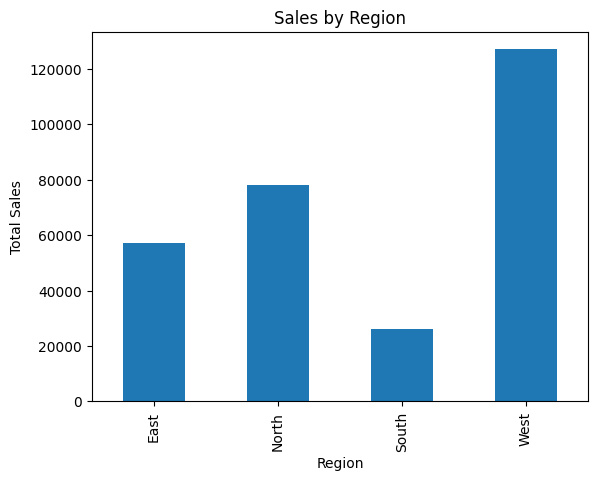

In [54]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

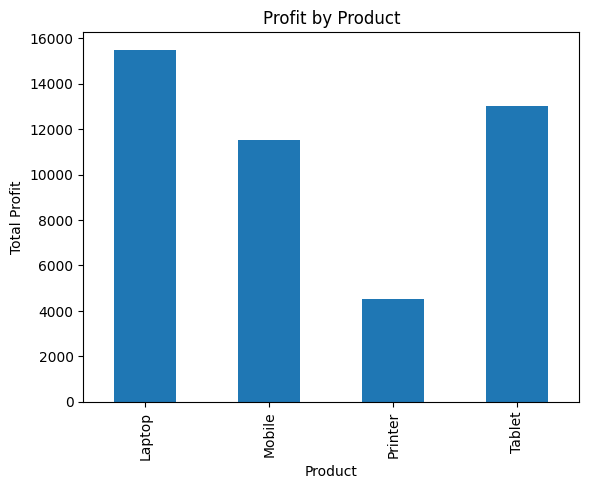

In [55]:
df.groupby('Product')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Product")
plt.ylabel("Total Profit")
plt.show()


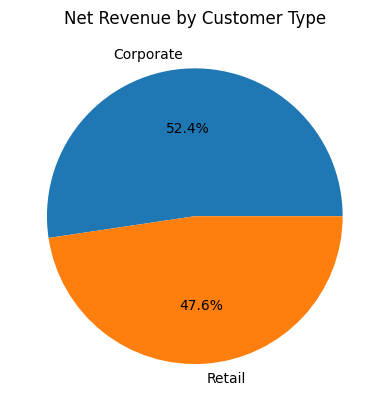

In [56]:
df.groupby('Customer_Type')['Net_Sale'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Net Revenue by Customer Type")
plt.ylabel("")
plt.show()


1. West Region contributes highest net revenue.
2. Laptop is the most profitable product.
3. Corporate customers receive higher discounts.
4. Discount strategy impacts profitability.
5. Sales concentration is higher in specific regions and products, indicating potential dependency risk.

<Axes: xlabel='Region'>

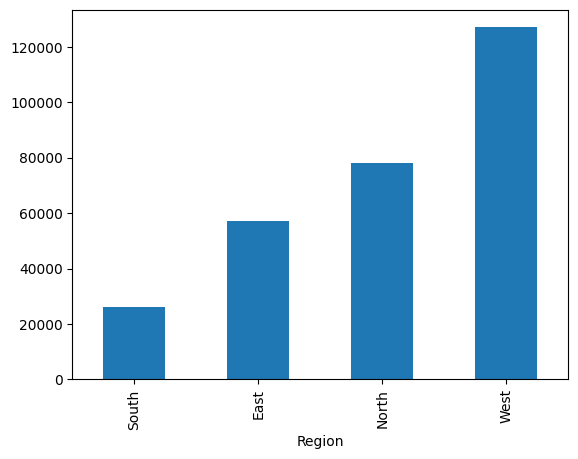

In [57]:
df.groupby('Region')['Sales'].sum().sort_values().plot(kind='bar')